In [1]:
%load_ext autoreload
%autoreload 2

**Author:** Salvador Navas  
**Date:** 2025-06-27

In [2]:
from pyhydra.data_sources.river_discharge import (
    read_grdc,
    read_grdc_metadata,
    read_grdc_folder,
    analyze_grdc_quality,
)
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd
import tempfile, os
from pathlib import Path
print('Imports OK')

Imports OK


# GRDC — Global Runoff Data Centre

## What is GRDC?

The **Global Runoff Data Centre (GRDC)** is the international repository for river discharge data,
operated by the German Federal Institute of Hydrology (BfG) on behalf of WMO.
It archives daily and monthly streamflow records from ~10,000 gauging stations worldwide,
with some records dating back to the 19th century.

| Property | Value |
|----------|-------|
| Provider | BfG (Germany) on behalf of WMO |
| Stations | ~10,000 worldwide |
| Resolution | Daily and monthly |
| Coverage | 1807–present (varies by station) |
| Access | Free (registration + data request required) |

## 🆚 GRDC vs GloFAS — when to use which?

| Aspect | GRDC | GloFAS |
|--------|------|--------|
| Data type | Observed (gauge) | Modelled (LISFLOOD+ERA5) |
| Accuracy | ✅ Ground truth | ⚠️ Bias 20–50% common |
| Availability | Gauged basins only | ✅ Global (any point) |
| Data access | Manual request (1–5 days) | API download |
| Consistency | Variable (different QC by country) | Consistent |

> **Use GRDC** when the basin has a gauge and you need calibration/validation data.
> **Use GloFAS** for ungauged basins or long consistent records without gaps.

## 📥 How to request GRDC data

GRDC **does not have a public download API**. Data is requested via the online portal:

1. Go to https://portal.grdc.bafg.de
2. Search by river name, country, or coordinates
3. Select stations and click **Request Data**
4. Fill in the request form (institution, purpose) — approval is usually within 1–5 working days
5. You receive a download link by email with `.day` (daily) or `.mon` (monthly) files

## 📄 File format

GRDC files are semicolon-delimited text with a metadata header:

```
# GRDC-No.: 6335020
# River: EBRO
# Station: ZARAGOZA
# YYYY-MM-DD;hh;Original;Calculated;Qualifier
2000-01-01; 00; 45.30; 45.30; G
```

The `Qualifier` field: `G` = good, `M` = missing (−999), `E` = estimated.
pyhydra automatically replaces −999 values with `NaN`.

## ⚠️ Data quality by region

- **Europe, North America, Australia**: High quality, long records, regular QC
- **South America, India**: Variable — some excellent records, others patchy
- **Africa, Central Asia**: Often short records, many gaps, use with caution


In [3]:
# === SYNTHETIC DEMO DATA ===
# Creates a temporary GRDC .day file in the exact format expected by read_grdc()

import numpy as np

TMPDIR = tempfile.mkdtemp()
GRDC_FILE = os.path.join(TMPDIR, '6335020.day')

rng = np.random.default_rng(42)
dates = pd.date_range('1990-01-01', '2020-12-31', freq='D')
# Seasonal discharge: base 80 m3/s + seasonal variation + noise
doy = dates.dayofyear.values  # convert to numpy array
discharge = 80 + 60 * np.sin(2 * np.pi * (doy - 60) / 365) + rng.normal(0, 10, len(dates))
discharge = np.clip(discharge, 5, None)
# Introduce ~2% missing values
missing_mask = rng.random(len(dates)) < 0.02
discharge[missing_mask] = -999.0

header = (
    '# GRDC STATION DATA FILE\n'
    '# GRDC-No.: 6335020\n'
    '# River: Ebro\n'
    '# Station: Zaragoza\n'
    '# Country: ES (Spain)\n'
    '# Latitude: 41.65\n'
    '# Longitude: -0.87\n'
    '# Altitude: 250\n'
    '# Catchment area: 40414\n'
    '# Unit: m3/s\n'
    '# Missing value: -999\n'
    '#\n'
    '# YYYY-MM-DD;hh;Original;Calculated;Qualifier\n'
)

with open(GRDC_FILE, 'w') as f:
    f.write(header)
    for d, q in zip(dates, discharge):
        f.write(f'{d.strftime("%Y-%m-%d")};00;{q:.2f};{q:.2f};G\n')

print(f'Synthetic GRDC file created: {GRDC_FILE}')
print(f'Records: {len(dates)}')

Synthetic GRDC file created: /var/folders/44/dw7p6q9108xcc4mmh_f7q1vc0000gn/T/tmp_hhnh379/6335020.day
Records: 11323


---
## 1. Reading a single GRDC file

---
## 1. Reading a single GRDC file

Use `read_grdc_metadata()` to inspect station attributes before loading the full series.
Then `read_grdc()` returns a DataFrame with columns `['date', 'discharge']`,
with −999 sentinel values already replaced by `NaN`.


In [4]:
# --- Read discharge series ---
df = read_grdc(GRDC_FILE).set_index('date')
meta = read_grdc_metadata(GRDC_FILE)
df.head()

In [5]:
# --- Quality statistics ---
q = analyze_grdc_quality(df.reset_index())
print(f"Period   : {q['start'].date()} → {q['end'].date()}")
print(f"N days   : {q['n_days']}")
print(f"Missing  : {q['missing_pct']} %")
print(f"Mean Q   : {q['mean_m3s']} m³/s")
print(f"Max  Q   : {q['max_m3s']} m³/s")

Period   : 1990-01-01 → 2020-12-31
N days   : 11323
Missing  : 2.11 %
Mean Q   : 79.861 m³/s
Max  Q   : 169.79 m³/s


---
### Interpreting quality statistics

| Metric | Good | Concern |
|--------|------|--------|
| `missing_pct` | < 5% | > 10%: exclude from frequency analysis |
| `mean_m3s` | Compare with published values | Order-of-magnitude error → wrong station |
| `max_m3s` | ~3–10× mean for Iberia | Very high max → check for transcription errors |

> **Tip:** Cross-check mean discharge against the catchment area and mean annual precipitation:
> `Q_mean ≈ P_annual × A × runoff_coeff / (365 × 86400)` — deviations > 50% warrant investigation.


Plot saved to /tmp/GRDC_download.png


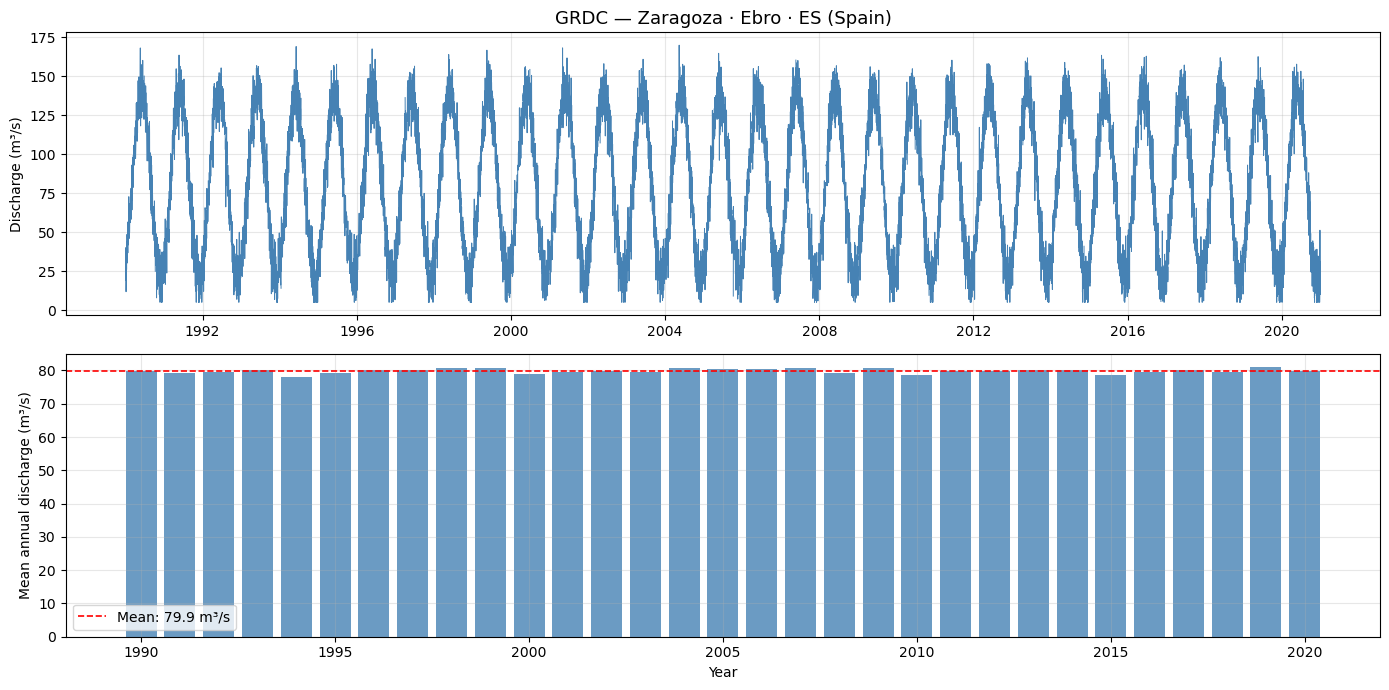

In [6]:
# --- Time series plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(df.index, df['discharge'], lw=0.7, color='steelblue')
axes[0].set_ylabel('Discharge (m³/s)')
axes[0].set_title(
    f"GRDC — {meta.get('station', 'Station')} · {meta.get('river', '')} · {meta.get('country', '')}",
    fontsize=13
)
axes[0].grid(alpha=0.3)

annual = df['discharge'].resample('YE').mean()
axes[1].bar(annual.index.year, annual.values, color='steelblue', alpha=0.8)
axes[1].axhline(annual.mean(), color='red', lw=1.2, ls='--',
                label=f"Mean: {annual.mean():.1f} m³/s")
axes[1].set_ylabel('Mean annual discharge (m³/s)')
axes[1].set_xlabel('Year')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/GRDC_download.png', dpi=100, bbox_inches='tight')
plt.close()
print('Plot saved to /tmp/GRDC_download.png')

---
## 2. Reading an entire folder of GRDC files

`read_grdc_folder()` scans a directory for all `.day` files and returns a dict
mapping `{station_id: DataFrame}`. Useful when you have downloaded data for multiple stations.

```python
all_data = read_grdc_folder('/path/to/grdc_folder/', pattern='*.day')
for station_id, df_station in all_data.items():
    q = analyze_grdc_quality(df_station)
    print(f'{station_id}: {q["mean_m3s"]} m³/s')
```


In [7]:
# Write a second synthetic station file
GRDC_FILE2 = os.path.join(TMPDIR, '6335021.day')
discharge2 = 120 + 80 * np.sin(2 * np.pi * (doy - 90) / 365) + rng.normal(0, 15, len(dates))
discharge2 = np.clip(discharge2, 5, None)
with open(GRDC_FILE2, 'w') as f:
    f.write(header.replace('6335020', '6335021').replace('Zaragoza', 'Tudela'))
    for d, q in zip(dates, discharge2):
        f.write(f'{d.strftime("%Y-%m-%d")};00;{q:.2f};{q:.2f};G\n')

all_data = read_grdc_folder(TMPDIR, pattern='*.day')
print(f'Stations loaded: {len(all_data)}')
for name, df_station in all_data.items():
    q = analyze_grdc_quality(df_station)
    print(f'  {name}: {q["n_days"]} days, {q["missing_pct"]}% missing, mean={q["mean_m3s"]} m³/s')

Stations loaded: 2
  6335020: 11323 days, 2.11% missing, mean=79.861 m³/s
  6335021: 11323 days, 0.0% missing, mean=120.213 m³/s


---
## 3. Seasonal regime

The monthly mean discharge reveals the **hydrological regime** of the basin:

| Pattern | Regime | Example (Iberia) |
|---------|--------|------------------|
| Spring peak (Mar–May) | **Nival** — snowmelt dominated | Ebro headwaters, Pyrenees |
| Winter peak (Dec–Feb) | **Pluvial** — rain dominated | Guadalquivir, Guadiana |
| Double peak | **Mixed** — snow + autumn rain | Ebro at Zaragoza |
| Summer low flow | All Mediterranean regimes | Most Iberian rivers |

In this synthetic demo, the peak is in March (DOY 60) — a typical nival signal.


Seasonal plot saved to /tmp/GRDC_seasonal.png


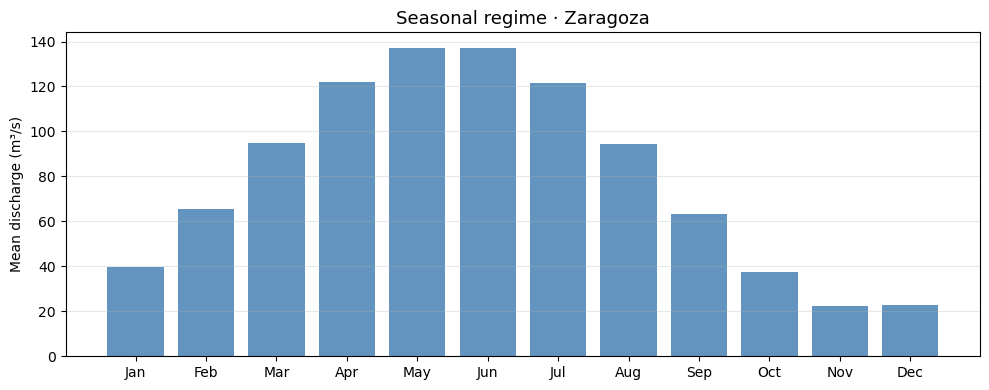

In [8]:
monthly_mean = df['discharge'].groupby(df.index.month).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly_mean.index, monthly_mean.values, color='steelblue', alpha=0.85)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('Mean discharge (m³/s)')
ax.set_title(f"Seasonal regime · {meta.get('station', 'GRDC station')}", fontsize=13)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/tmp/GRDC_seasonal.png', dpi=100, bbox_inches='tight')
plt.close()
print('Seasonal plot saved to /tmp/GRDC_seasonal.png')

---
## 📊 Next steps: validation and frequency analysis

After loading GRDC data, the standard workflow is:

1. **Compare against GloFAS** to assess model bias:
   ```python
   bias = df_grdc['discharge'].mean() / df_glofas['discharge'].mean()
   print(f'GloFAS bias: {bias:.2f}×')
   ```

2. **Flood frequency analysis** — fit GEV to annual maxima:
   ```python
   annual_max = df_grdc['discharge'].resample('YE').max().dropna()
   # → see extreme_value_analysis notebook
   ```

3. **Low-flow analysis** — compute Q90 from flow duration curve:
   ```python
   Q90 = df_grdc['discharge'].quantile(0.10)  # exceeded 90% of the time
   ```

4. **HEC-HMS calibration** — use daily observed flow as calibration target:
   → see `HEC_HMS` notebook
